In [1]:
 pip install fastai --upgrade 

In [2]:
from fastai.vision.all import *

In [3]:
path='C:/Plant Diseases/archive (1)/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'

In [4]:
fns=get_image_files(path)
fns

(#87867) [Path('C:/Plant Diseases/archive (1)/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG'),Path('C:/Plant Diseases/archive (1)/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG'),Path('C:/Plant Diseases/archive (1)/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003_270deg.JPG'),Path('C:/Plant Diseases/archive (1)/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003_90deg.JPG'),Path('C:/Plant Diseases/archive (1)/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 300

In [5]:
leaf=DataBlock(blocks=(ImageBlock,CategoryBlock),
               get_items=get_image_files,
               splitter=RandomSplitter(valid_pct=(0.2),seed=42),
               get_y=parent_label,item_tfms=Resize(224))

In [6]:
dls=leaf.dataloaders(path,num_workers = 0,bs=64)

In [7]:
learner=vision_learner(dls,resnet18,metrics=[accuracy, error_rate])

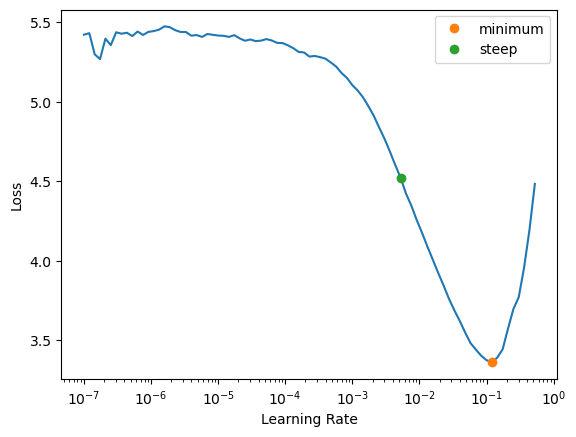

In [8]:
lr_min,lr_steep = learner.lr_find(suggest_funcs=(minimum,steep))

In [9]:
print(f"Minimum/10: {lr_min:.2e}, steepest point: {lr_steep:.2e}")

Minimum/10: 1.20e-02, steepest point: 5.25e-03


In [10]:
lr_steep

0.005248074419796467

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.261792,0.107372,0.966198,0.033802,57:02


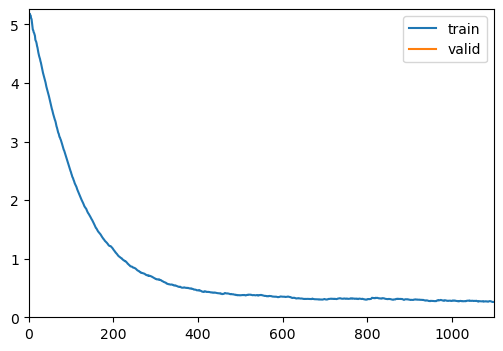

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,0.121512,0.051886,0.983327,0.016673,18:06
1,0.039258,0.020109,0.993399,0.006601,18:02
2,0.006337,0.005602,0.997838,0.002162,18:01


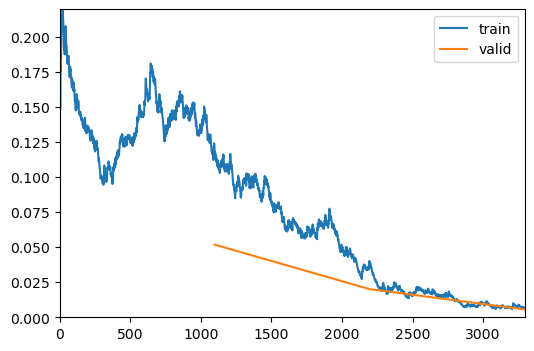

In [11]:
learner.fine_tune(3,base_lr=lr_steep,cbs=[ShowGraphCallback()])

In [ ]:
print()